<a href="https://colab.research.google.com/github/jollactic/MuFinder_MACE/blob/main/MuFinder_MACE_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MuFinder + MACE: a first muon-site search

This notebook runs a deliberately small positive-muon (μ⁺) site search in γ-Al₂O₃ using **MuFinder** for candidate sites and **MACE-MP** for relaxation.

For a quick tutorial we use only **20 candidate sites**. This is may not be enough for a production search; it is chosen so the complete workflow can be explored interactively.

`host optimization → candidate μ sites → relaxation → clustering → harmonic μ ZPE`

The host-subtracted insertion energy is
$$
E_{\mathrm{insert}}=E(X+\mu)-E(X).
$$

The isolated-muon reference is omitted, so comparisons require a consistent model/reference.

## 1. Check the runtime

A GPU is recommended. The notebook falls back to CPU.

In [1]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if DEVICE == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Device : cuda
GPU    : Tesla T4


## 2. Install dependencies

In [2]:
# Core packages
!pip -q install ase mace-torch

# MuFinder is installed from its GitLab repository
!pip -q install git+https://gitlab.com/BenHuddart/mufinder.git

# Restore the requests version required by Google Colab
!pip -q install requests==2.32.4

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.0/316.0 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.5/228.5 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.8/346.8 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.5/457.5 kB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 6.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━

In [3]:
import sys
from pathlib import Path

site_packages = Path(
    next(p for p in sys.path if "site-packages" in p or "dist-packages" in p)
)

init_file = site_packages / "mufinder" / "__init__.py"

text = init_file.read_text()
text = text.replace(
    'matplotlib.use("TkAgg")',
    'matplotlib.use("Agg")'
)
init_file.write_text(text)

print("Patched:", init_file)

Patched: /usr/local/lib/python3.13/dist-packages/mufinder/__init__.py


In [4]:
import matplotlib
import mufinder
from mufinder.core.sitegen.gen_sites import gen_random

print("MuFinder  : OK")
print("Matplotlib:", matplotlib.get_backend())

MuFinder  : OK
Matplotlib: Agg


In [5]:
import ase
import mace
import mufinder

from mufinder.core.sitegen.gen_sites import gen_random

print("ASE       : OK")
print("MACE      : OK")
print("MuFinder  : OK")
print("gen_random: OK")

ASE       : OK
MACE      : OK
MuFinder  : OK
gen_random: OK


## 3. Download the workflow and γ-Al₂O₃ example from GitHub

In [6]:
# ============================================================
# DOWNLOAD MUFINDER + MACE WORKFLOW
# ============================================================

from urllib.request import urlretrieve

BASE = "https://raw.githubusercontent.com/jollactic/MuFinder_MACE/main"

urlretrieve(
    f"{BASE}/mufinder_mace.py",
    "mufinder_mace.py"
)

print("Downloaded mufinder_mace.py")

Downloaded mufinder_mace.py


In [7]:
# ============================================================
# CHOOSE STRUCTURE
# ============================================================

USE_OWN_STRUCTURE = False

In [8]:
from urllib.request import urlretrieve
from pathlib import Path

if USE_OWN_STRUCTURE:
    from google.colab import files

    uploaded = files.upload()

    if len(uploaded) != 1:
        raise RuntimeError("Please upload exactly one structure file.")

    STRUCTURE = next(iter(uploaded))

else:
    BASE = "https://raw.githubusercontent.com/jollactic/MuFinder_MACE/main"

    STRUCTURE = "gamma_Al2O3.cif"

    urlretrieve(
        f"{BASE}/examples/gamma_Al2O3.cif",
        STRUCTURE
    )

print("Structure:", STRUCTURE)



Structure: gamma_Al2O3.cif


## 4. Inspect the starting structure

In [9]:
from ase.io import read
host = read("gamma_Al2O3.cif")
print("Formula      :", host.get_chemical_formula())
print("Number atoms :", len(host))
print("Cell:")
print(host.cell)

Formula      : Al16O24
Number atoms : 40
Cell:
Cell([[5.587, 0.0, 0.0], [0.0, 8.413, 0.0], [-0.0830782985384609, 0.0, 8.067572249215491]])


## 5. Tutorial settings

We use only two sites for speed. `full` allows the host atoms to relax around the muon after pristine-host/cell optimization.

In [10]:
N_SITES = 20
LEVEL = "full"
MODEL = "medium"
DISPERSION = False
ZPE = True

## 6. Create `muon.in`

The same input format can be used later on a workstation or HPC system.

In [11]:
input_text = f"""structure = gamma_Al2O3.cif

level = {LEVEL}
supercell = 1 1 1
n_sites = {N_SITES}

calculator = mace-mp
model = {MODEL}
dispersion = {str(DISPERSION).lower()}

device = {DEVICE}
dtype = float64

zpe = {str(ZPE).lower()}
"""
with open("muon.in", "w") as f:
    f.write(input_text)
print(input_text)

structure = gamma_Al2O3.cif

level = full
supercell = 1 1 1
n_sites = 20

calculator = mace-mp
model = medium
dispersion = false

device = cuda
dtype = float64

zpe = true



## 7. Run the calculation

The first run may take some time because the model is downloaded and the pristine host is optimized. The workflow is resumable.

In [12]:
!python mufinder_mace.py muon.in

MuFinder + MACE workflow
{'level': 'full', 'supercell': [1, 1, 1], 'n_sites': 20, 'zpe': True, 'dispersion': False, 'calculator': 'mace-mp', 'model': 'medium', 'device': 'cuda', 'dtype': 'float64', 'minr': 0.5, 'vdws': 1.0, 'seed': 123, 'host_fmax': 0.02, 'host_steps': 500, 'muon_fmax': 0.02, 'muon_steps': 500, 'cluster_tol': 0.5, 'zpe_delta': 0.005, 'muon_mass': 0.11342892566, 'output_dir': 'muon_candidates', 'structure': 'gamma_Al2O3.cif'}
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Downloading: 100.0% (42.4 MB / 42.4 MB)
Cached MACE model to /root/.cache/mace/20231203mace128L1_epoch199model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Host converged: True
site_000: E=-299.66800211 eV nearest=O21 1.016 A
site_001: E=-299.88056391 eV nearest=O19 1.015 A
site_002: 

## 8. Check status

This inspects files only and does not start new MACE calculations.

In [13]:
!python mufinder_mace.py muon.in --status


 MUON WORKFLOW STATUS
Host prepared         : yes
Generated sites       : 20
Relaxed structures    : 20 / 20
Completed sites       : 20 / 20
Clustering completed  : yes
Final results.json    : yes
ZPE summary           : yes


## 9. Read `results.json`

In [14]:
import json
import pandas as pd

with open("muon_candidates/results.json") as f:
    results = json.load(f)

rows = []
for s in results["sites"]:
    rows.append({
        "site": s["site"],
        "dE (eV)": s["delta_energy_eV"],
        "Einsert (eV)": s.get("insertion_energy_eV"),
        "ZPE (eV)": s.get("zpe_eV"),
        "Einsert+ZPE (eV)": s.get("corrected_insertion_energy_eV"),
        "dE_ZPE (eV)": s.get("delta_corrected_eV"),
        "nearest": f'{s["nearest"]["element"]}{s["nearest"]["index"]}',
        "r (Å)": s["nearest"]["distance_A"],
    })
df = pd.DataFrame(rows)
df

,site,dE (eV),Einsert (eV),ZPE (eV),Einsert+ZPE (eV),dE_ZPE (eV),nearest,r (Å)
0,site_004,0.000000,-2.987170,0.862035,-2.125134,0.000000,O31,0.988204
1,site_009,0.000063,-2.987106,NaN,NaN,NaN,O31,0.988159
2,site_011,0.000180,-2.986990,0.863093,-2.123897,0.001238,O28,0.988010
3,site_016,0.000258,-2.986911,NaN,NaN,NaN,O31,0.988088
4,site_017,0.000277,-2.986893,0.862573,-2.124320,0.000815,O29,0.987593
5,site_015,0.034678,-2.952492,0.870686,-2.081806,0.043328,O37,0.997979
6,site_018,0.034703,-2.952467,0.870189,-2.082277,0.042857,O38,0.997830
7,site_006,0.034836,-2.952334,NaN,NaN,NaN,O37,0.997507
8,site_008,0.380922,-2.606247,0.877017,-1.729230,0.395904,O32,0.997454
9,site_003,0.380957,-2.606212,NaN,NaN,NaN,O32,0.997156


### Interpreting the energies

The insertion energy is defined as

$$
E_{\mathrm{insert}} = E(X+\mu) - E(X).
$$

With the optional harmonic zero-point energy correction,

$$
E_{\mathrm{insert}}^{\mathrm{ZPE}}
=
E_{\mathrm{insert}} + E_{\mathrm{ZPE}}.
$$

`dE` and `dE_ZPE` are relative to the lowest static and ZPE-corrected
candidate, respectively.

Because the muon is very light, its zero-point energy can substantially
alter the energetic separation and potentially the ordering of candidate
muon sites.

## 10. Plot static and ZPE-corrected insertion energies

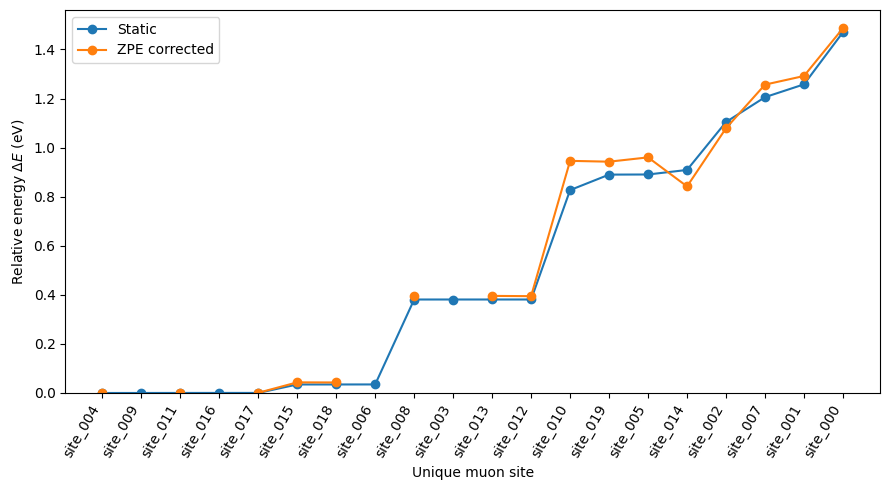

In [15]:
%matplotlib inline
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

plot_df = df.sort_values("dE (eV)").reset_index(drop=True)
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    x, plot_df["dE (eV)"],
    "o-", label="Static"
)

if plot_df["dE_ZPE (eV)"].notna().any():
    ax.plot(
        x, plot_df["dE_ZPE (eV)"],
        "o-", label="ZPE corrected"
    )

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["site"],
    rotation=60,
    ha="right"
)

ax.set_ylabel(r"Relative energy $\Delta E$ (eV)")
ax.set_xlabel("Unique muon site")
ax.set_ylim(bottom=0)

ax.legend()
fig.tight_layout()
plt.show()

## 11. Inspect the lowest-energy relaxed site

In [16]:
best = min(results["sites"], key=lambda x: x["energy_eV"])
best_site = best["site"]
relaxed = read(f"muon_candidates/{best_site}/relaxed.extxyz")

print("Lowest static site :", best_site)
print("Insertion energy   :", best.get("insertion_energy_eV"), "eV")
print("Nearest host atom  :", f'{best["nearest"]["element"]}{best["nearest"]["index"]}')
print("Distance           :", best["nearest"]["distance_A"], "Å")
print("Formula            :", relaxed.get_chemical_formula())

Lowest static site : site_004
Insertion energy   : -2.9871697772385915 eV
Nearest host atom  : O31
Distance           : 0.9882043842898203 Å
Formula            : HAl16O24


## Where to go next

This tutorial samples 20 initial muon positions, providing a useful first
exploration of the possible stopping sites. Several starting positions may
relax to the same minimum, so the number and character of the resulting
unique sites are more important than the number of initial candidates.

For a quantitative study, check that the low-energy sites are stable with
respect to increased site sampling and supercell size. The suitability of
the chosen MACE model for the material should also be considered, and the
relaxed structures should always be inspected alongside their energies.

Finally, remember that the ZPE correction used here is harmonic. For a
particle as light as the muon, anharmonicity and tunnelling may become
important and require a more complete quantum treatment.